In [267]:
# importing required libraries
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)


#### Importing the cleaned dataset

In [269]:
dfT1DData = pd.read_excel("C:/Users/bhara/Documents/Python Data Analysis/Type 1 Diabetes Dataset/Type1_Diabetes_Analysis.xlsx")

#### Demographic breakdown of patients

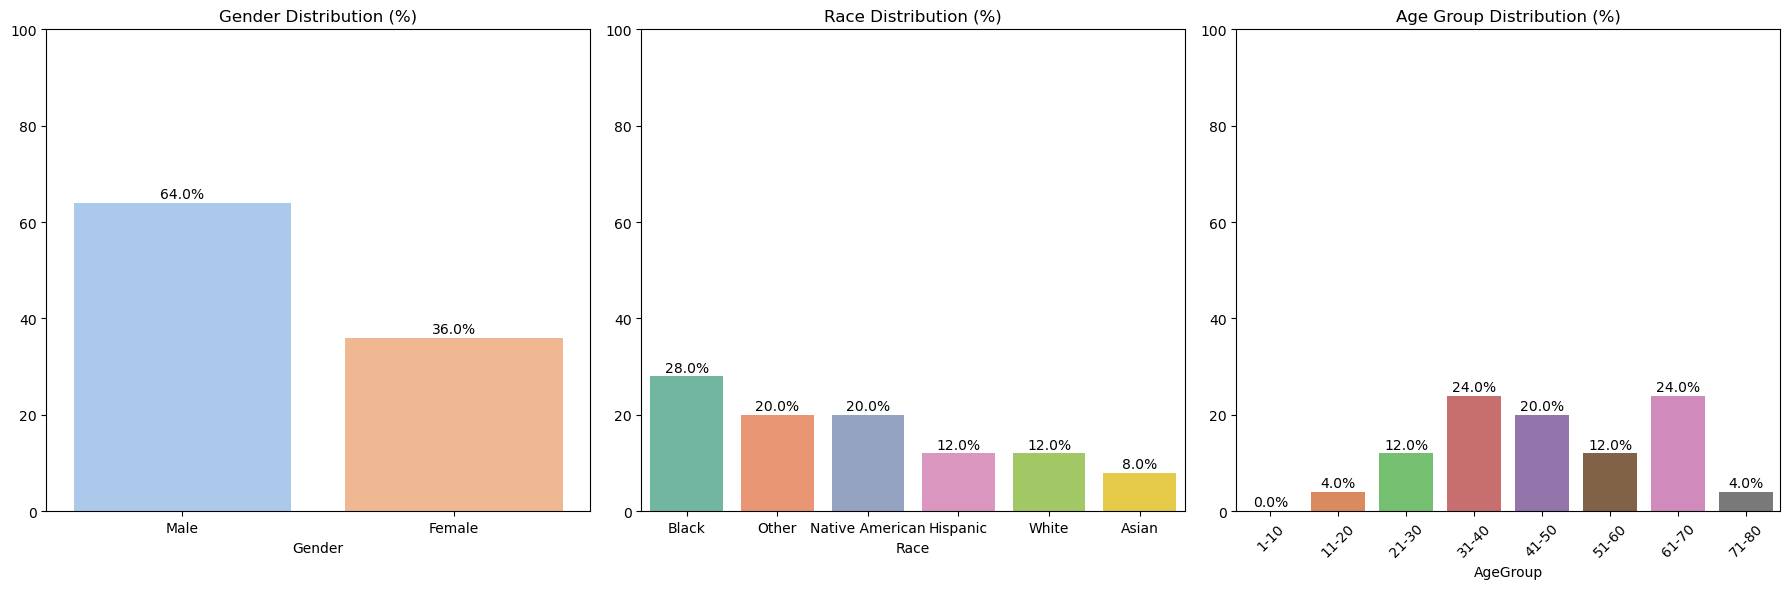

In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a dataframe for demographics data with unique patient-ids ---
dfdemo = dfT1DData[['patient_id', 'Age', 'Gender', 'Race']].drop_duplicates()

# Creating 10-year age groups starting at 1 ---
bins = range(1, dfdemo['Age'].max() + 10, 10)
labels = [f"{i}-{i+9}" for i in bins[:-1]]
dfdemo['AgeGroup'] = pd.cut(dfdemo['Age'], bins=bins, labels=labels, right=True)

# calculate percentages ---
gender_counts = dfdemo['Gender'].value_counts(normalize=True) * 100
race_counts = dfdemo['Race'].value_counts(normalize=True) * 100
age_counts = dfdemo['AgeGroup'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gender
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette="pastel")
axes[0].set_title("Gender Distribution (%)")
axes[0].set_ylim(0, 100)  # standardize to percentage scale
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center')

# Race
sns.barplot(x=race_counts.index, y=race_counts.values, ax=axes[1], palette="Set2")
axes[1].set_title("Race Distribution (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(race_counts.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center')

# Age groups
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[2], palette="muted")
axes[2].set_title("Age Group Distribution (%)")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


#### Average sleep duration across all patients?

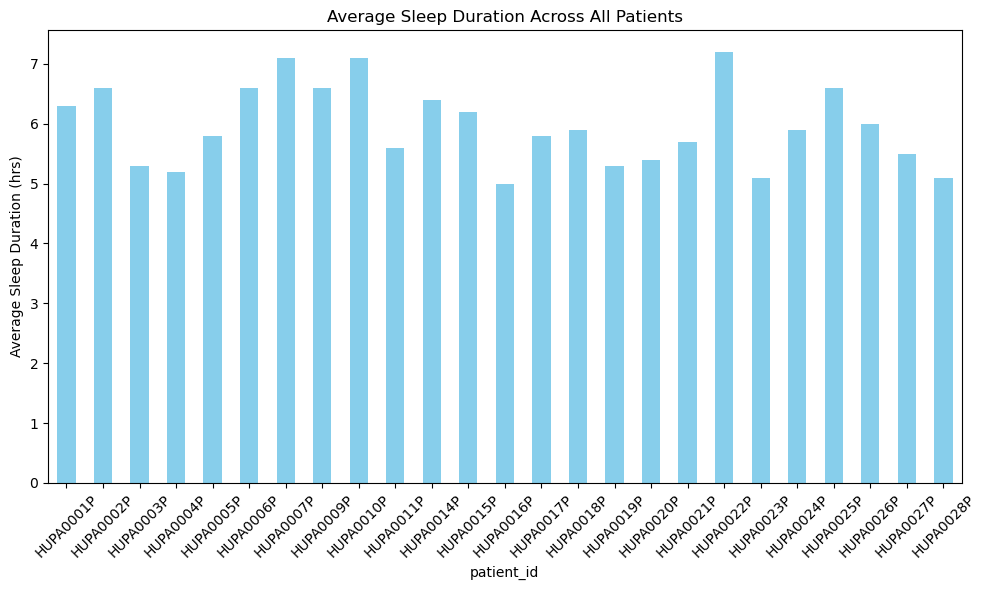

In [273]:

import matplotlib.pyplot as plt

# calculating average sleep duration ---
avg_sleep = dfT1DData.groupby("patient_id")["Average Sleep Duration (hrs)"].mean()

# for plot ---
plt.figure(figsize=(10,6))
avg_sleep.plot(kind='bar', color = 'skyblue')
plt.title("Average Sleep Duration Across All Patients")
plt.xlabel("patient_id")
plt.ylabel("Average Sleep Duration (hrs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Proportion of patients getting less than 6 hours of sleep?

In [275]:

# Count patients with < 6 hrs sleep
patients_less_than_6 = (avg_sleep < 6).sum()

# Calculate proportion
total_patients = avg_sleep.shape[0]
proportion = patients_less_than_6 / total_patients

print(f"Patients with < 6 hrs sleep: {patients_less_than_6} out of {total_patients}")
print(f"Proportion: {proportion:.2%}")

Patients with < 6 hrs sleep: 14 out of 25
Proportion: 56.00%


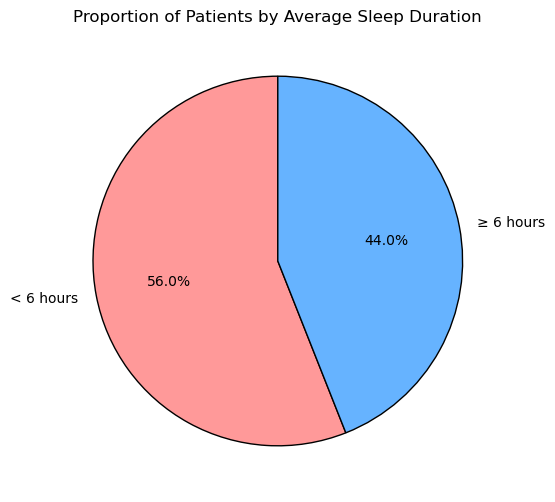

In [276]:
import matplotlib.pyplot as plt

# Average sleep duration per patient
avg_sleep = dfT1DData.groupby("patient_id")["Average Sleep Duration (hrs)"].mean()

# Count patients by category
less_than_6 = (avg_sleep < 6).sum()
greater_equal_6 = (avg_sleep >= 6).sum()

# Plot pie chart
labels = ['< 6 hours', '≥ 6 hours']
sizes = [less_than_6, greater_equal_6]
colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor':'black'})
plt.title("Proportion of Patients by Average Sleep Duration")
plt.show()

#### Average glucose level per participant

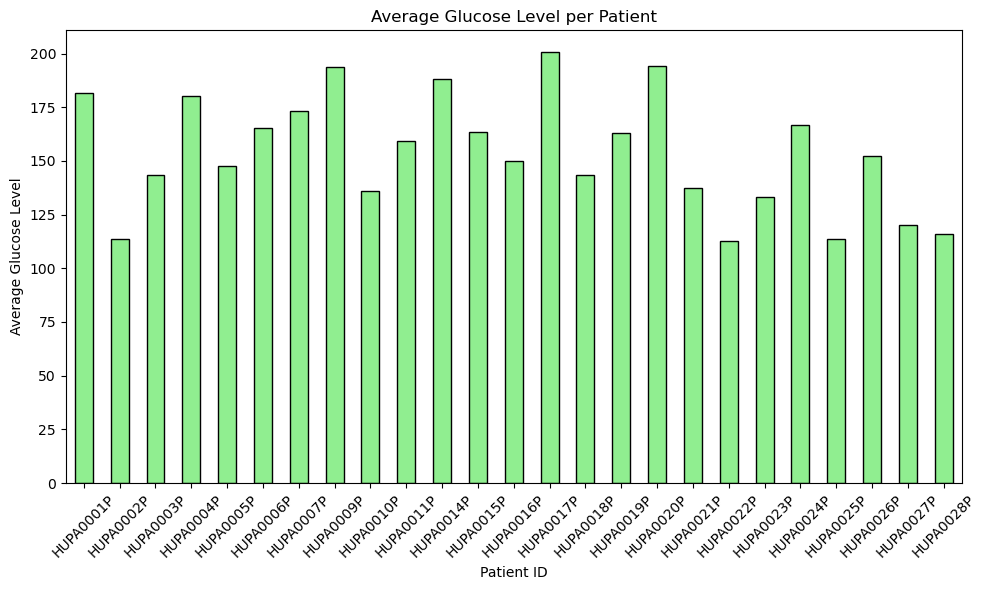

In [278]:
# Average glucose per participant
avg_glucose = dfT1DData.groupby("patient_id")["glucose"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
avg_glucose.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Average Glucose Level per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Proportion of glucose readings are below 70 (hypoglycemia) or above 180 (hyperglycemia)

In [280]:
# Total number of glucose readings
total_readings = dfT1DData["glucose"].count()

# Hypoglycemia (<70)
hypo_count = (dfT1DData["glucose"] < 70).sum()

# Hyperglycemia (>180)
hyper_count = (dfT1DData["glucose"] > 180).sum()

# Proportions
hypo_prop = hypo_count / total_readings
hyper_prop = hyper_count / total_readings

print(f"Hypoglycemia (<70): {hypo_count} readings ({hypo_prop:.2%})")
print(f"Hyperglycemia (>180): {hyper_count} readings ({hyper_prop:.2%})")

Hypoglycemia (<70): 6991 readings (7.76%)
Hyperglycemia (>180): 27745 readings (30.79%)


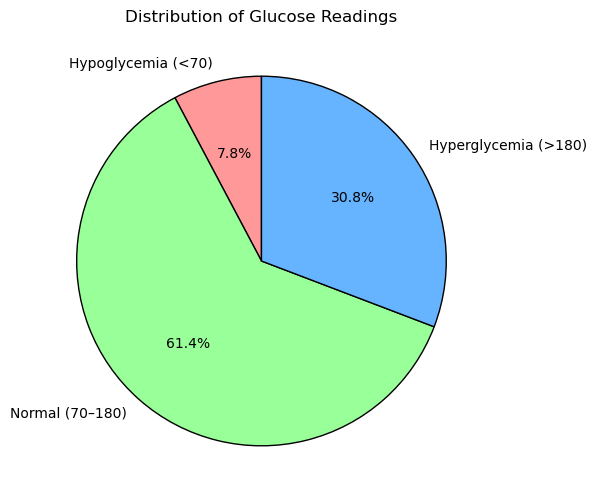

In [281]:
import matplotlib.pyplot as plt

labels = ['Hypoglycemia (<70)', 'Normal (70–180)', 'Hyperglycemia (>180)']
counts = [
    hypo_count,
    total_readings - (hypo_count + hyper_count),
    hyper_count
]
colors = ['#ff9999','#99ff99','#66b3ff']

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor':'black'})
plt.title("Distribution of Glucose Readings")
plt.show()

#### How does glucose variability (standard deviation) differ across participants?

In [283]:
# Standard deviation of glucose per participant
glucose_sd = dfT1DData.groupby("patient_id")["glucose"].std()

# coefficient of variation
glucose_cv = (dfT1DData.groupby("patient_id")["glucose"].std() /
              dfT1DData.groupby("patient_id")["glucose"].mean()) * 100

print("Glucose Variability (Standard Deviation):")
print(glucose_sd)

print("\nGlucose Variability (Coefficient of Variation %):")
print(glucose_cv)

Glucose Variability (Standard Deviation):
patient_id
HUPA0001P    70.644635
HUPA0002P    59.145069
HUPA0003P    61.326544
HUPA0004P    83.020748
HUPA0005P    49.791132
HUPA0006P    84.736090
HUPA0007P    78.656652
HUPA0009P    46.109885
HUPA0010P    57.606616
HUPA0011P    57.085515
HUPA0014P    72.458575
HUPA0015P    68.044103
HUPA0016P    79.837163
HUPA0017P    69.448531
HUPA0018P    70.269565
HUPA0019P    60.540289
HUPA0020P    78.785654
HUPA0021P    45.975802
HUPA0022P    40.406056
HUPA0023P    43.189131
HUPA0024P    66.546138
HUPA0025P    40.052717
HUPA0026P    68.483689
HUPA0027P    42.615310
HUPA0028P    33.069724
Name: glucose, dtype: float64

Glucose Variability (Coefficient of Variation %):
patient_id
HUPA0001P    38.934735
HUPA0002P    52.124126
HUPA0003P    42.803823
HUPA0004P    46.025987
HUPA0005P    33.711304
HUPA0006P    51.291609
HUPA0007P    45.426364
HUPA0009P    23.799968
HUPA0010P    42.391266
HUPA0011P    35.878339
HUPA0014P    38.529137
HUPA0015P    41.612423
HUPA

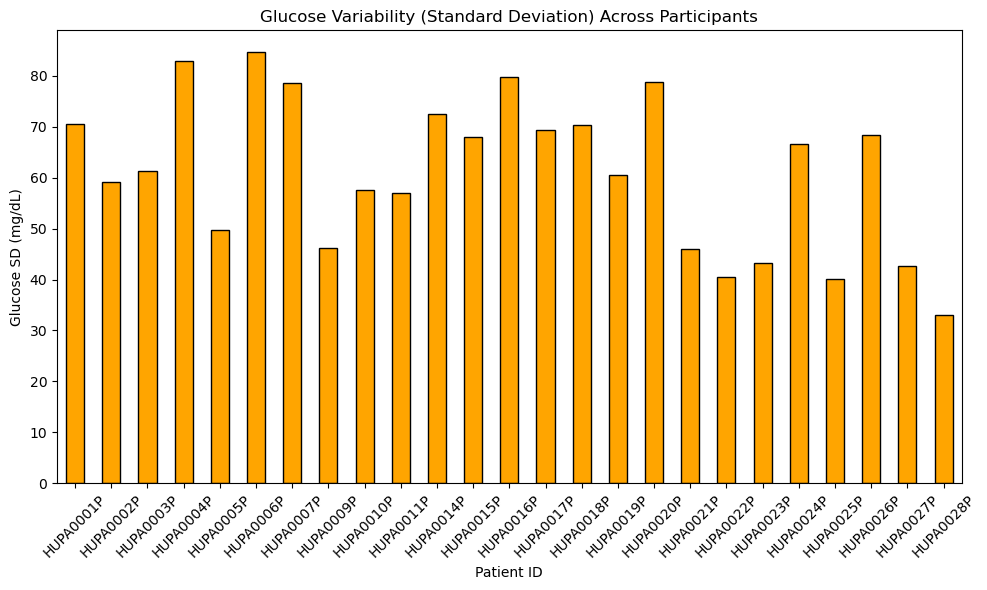

In [284]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
glucose_sd.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Glucose Variability (Standard Deviation) Across Participants")
plt.xlabel("Patient ID")
plt.ylabel("Glucose SD (mg/dL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Do males and females differ in average sleep duration?

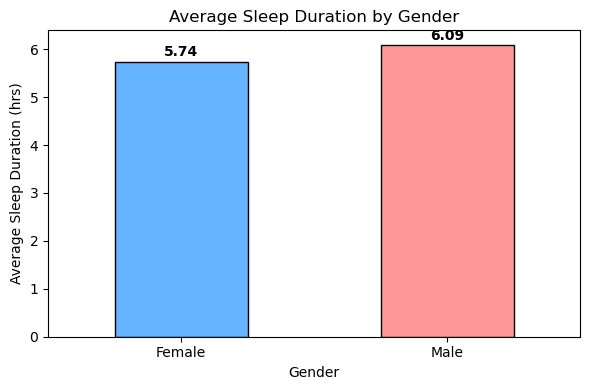

In [286]:
import matplotlib.pyplot as plt

# Average sleep duration by gender
sleep_by_gender = dfT1DData.groupby("Gender")["Average Sleep Duration (hrs)"].mean()

# Plot bar chart
plt.figure(figsize=(6,4))
bars = sleep_by_gender.plot(kind='bar', color=['#66b3ff', '#ff9999'], edgecolor='black')

plt.title("Average Sleep Duration by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sleep Duration (hrs)")
plt.xticks(rotation=0)

# Adding data labels on top of bars
for i, value in enumerate(sleep_by_gender):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### How does sleep duration vary across different age groups (<30, 30–40, 40–50, >50)?

  age_group  mean_sleep  n_patients
0       <30    6.133333           3
1     30–40    6.171429           7
2     40–50    5.860000           5
3       >50    5.840000          10


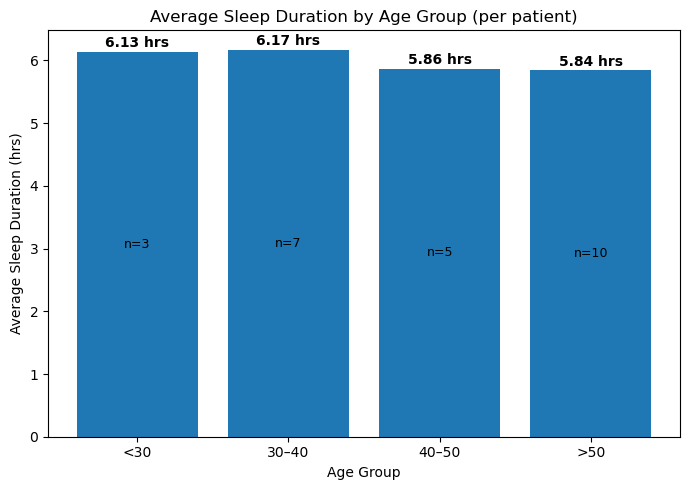

In [288]:

# Making sure Age is numeric and drop rows without Age or Sleep
df = dfT1DData.copy()
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df.dropna(subset=["Age", "Average Sleep Duration (hrs)"])

# --- 2) Per-patient averages (sleep) and a single age per patient ---
patient_sleep = (
    df.groupby("patient_id", as_index=False)
      .agg(
          avg_sleep_hrs=("Average Sleep Duration (hrs)", "mean"),
          age=("Age", "first")  # assuming Age is constant per patient
      )
)

# --- 3) Bin ages into requested groups ---
bins   = [-float("inf"), 30, 40, 50, float("inf")]
labels = ["<30", "30–40", "40–50", ">50"]
patient_sleep["age_group"] = pd.cut(patient_sleep["age"], bins=bins, labels=labels, right=False)

# --- 4) Aggregate by age group ---
by_group = (
    patient_sleep
    .groupby("age_group", observed=True)
    .agg(
        mean_sleep=("avg_sleep_hrs", "mean"),
        n_patients=("avg_sleep_hrs", "size")
    )
    .reset_index()
    .sort_values("age_group")
)

print(by_group)

# --- 5) Plot with data labels on bars ---
plt.figure(figsize=(7,5))
bars = plt.bar(by_group["age_group"].astype(str), by_group["mean_sleep"])

plt.title("Average Sleep Duration by Age Group (per patient)")
plt.xlabel("Age Group")
plt.ylabel("Average Sleep Duration (hrs)")
plt.xticks(rotation=0)

# Add numeric labels on bars (mean sleep) and show n
for i, (m, n) in enumerate(zip(by_group["mean_sleep"], by_group["n_patients"])):
    plt.text(i, m + 0.03, f"{m:.2f} hrs", ha="center", va="bottom", fontsize=10, fontweight="bold")
    plt.text(i, m/2, f"n={n}", ha="center", va="center", fontsize=9)  # shows sample size

plt.tight_layout()
plt.show()

#### Is there a correlation between sleep duration and sleep quality?

In [290]:
# Correlation between sleep duration and sleep quality
corr = dfT1DData["Average Sleep Duration (hrs)"].corr(dfT1DData["Sleep Quality (1-10)"])
print(f"Correlation: {corr:.2f}")

Correlation: 0.87


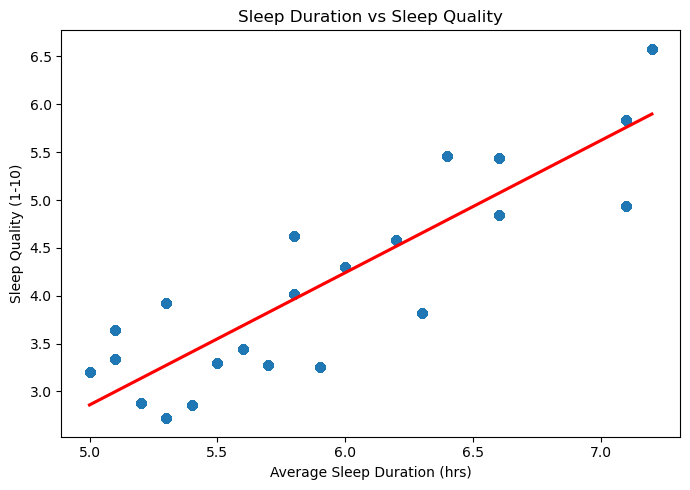

In [291]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(
    data=dfT1DData,
    x="Average Sleep Duration (hrs)",
    y="Sleep Quality (1-10)",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Sleep Duration vs Sleep Quality")
plt.xlabel("Average Sleep Duration (hrs)")
plt.ylabel("Sleep Quality (1-10)")
plt.tight_layout()
plt.show()

#### What are the daily glucose trends (morning vs evening vs night)?

         time_of_day     glucose
0  Afternoon (12-18)  154.163861
1    Evening (18-24)  152.659948
2     Morning (6-12)  154.744426
3        Night (0-6)  151.566001


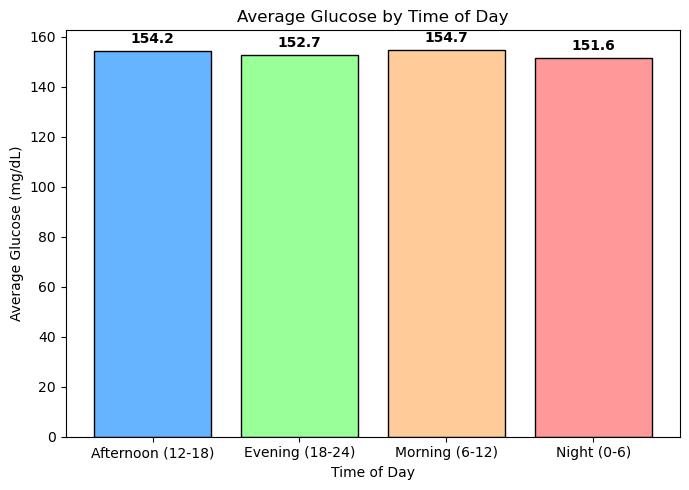

In [293]:
# Make sure time is in datetime format
df = dfT1DData.copy()
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

# Extract hour of day
df["hour"] = df["date_time"].dt.hour

# Define bins for time of day
def time_of_day(hour):
    if 6 <= hour < 12:
        return "Morning (6-12)"
    elif 12 <= hour < 18:
        return "Afternoon (12-18)"
    elif 18 <= hour < 24:
        return "Evening (18-24)"
    else:
        return "Night (0-6)"

df["time_of_day"] = df["hour"].apply(time_of_day)

# Group by time of day and compute average glucose
glucose_trends = df.groupby("time_of_day")["glucose"].mean().reset_index()

print(glucose_trends)

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(glucose_trends["time_of_day"], glucose_trends["glucose"],
               color=["#66b3ff","#99ff99","#ffcc99","#ff9999"], edgecolor="black")

plt.title("Average Glucose by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Glucose (mg/dL)")

# Add data labels
for i, v in enumerate(glucose_trends["glucose"]):
    plt.text(i, v + 2, f"{v:.1f}", ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

#### What is the average basal insulin delivered per participant?

In [295]:
# Average basal insulin per participant
avg_basal = dfT1DData.groupby("patient_id")["basal_rate"].mean().reset_index()

print(avg_basal.head())

  patient_id  basal_rate
0  HUPA0001P    0.050352
1  HUPA0002P    0.089447
2  HUPA0003P    0.054557
3  HUPA0004P    0.073505
4  HUPA0005P    0.067564


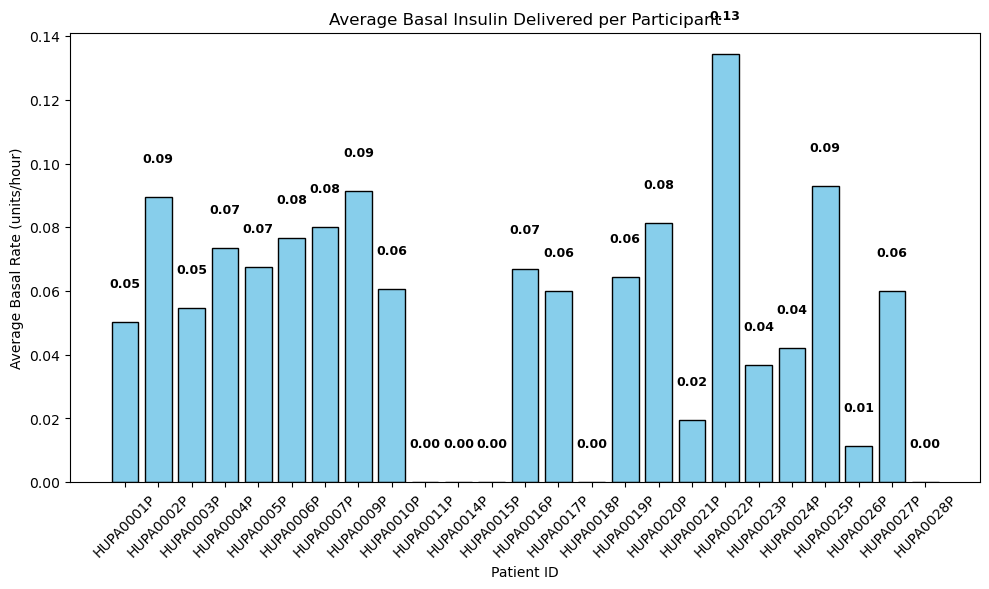

In [296]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
bars = plt.bar(avg_basal["patient_id"], avg_basal["basal_rate"], color="skyblue", edgecolor="black")

plt.title("Average Basal Insulin Delivered per Participant")
plt.xlabel("Patient ID")
plt.ylabel("Average Basal Rate (units/hour)")
plt.xticks(rotation=45)

# Add data labels
for i, v in enumerate(avg_basal["basal_rate"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

#### What is the average bolus insulin delivered per day?

In [298]:
# Daily total bolus per patient
daily_bolus = dfT1DData.groupby(["patient_id", "date"])["bolus_volume_delivered"].sum().reset_index()

# Average bolus per day (across days, per patient)
avg_bolus_per_day = daily_bolus.groupby("patient_id")["bolus_volume_delivered"].mean().reset_index()
avg_bolus_per_day.rename(columns={"bolus_volume_delivered": "avg_bolus_per_day"}, inplace=True)

print(avg_bolus_per_day.head())

  patient_id  avg_bolus_per_day
0  HUPA0001P          10.506667
1  HUPA0002P          19.391667
2  HUPA0003P          19.194286
3  HUPA0004P          39.591667
4  HUPA0005P           7.192857


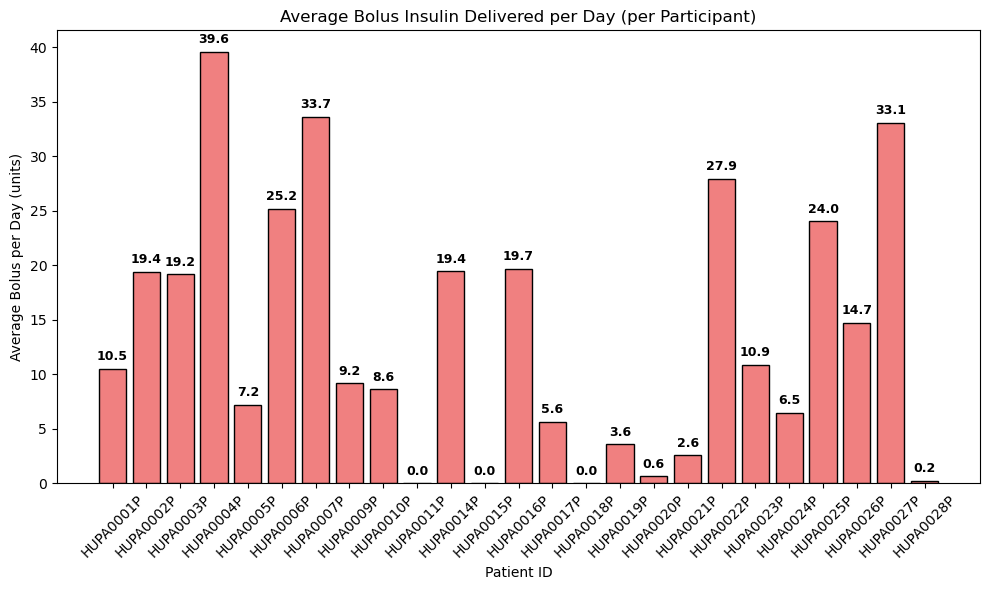

In [299]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
bars = plt.bar(avg_bolus_per_day["patient_id"], avg_bolus_per_day["avg_bolus_per_day"],
               color="lightcoral", edgecolor="black")

plt.title("Average Bolus Insulin Delivered per Day (per Participant)")
plt.xlabel("Patient ID")
plt.ylabel("Average Bolus per Day (units)")
plt.xticks(rotation=45)

# Add data labels
for i, v in enumerate(avg_bolus_per_day["avg_bolus_per_day"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

#### What is the average daily carb intake across participants?

In [301]:
# Daily total carb intake per patient
daily_carbs = dfT1DData.groupby(["patient_id", "date"])["carb_input_g"].sum().reset_index()

# Average daily carbs per participant
avg_carbs_per_day = daily_carbs.groupby("patient_id")["carb_input_g"].mean().reset_index()
avg_carbs_per_day.rename(columns={"carb_input_g": "avg_daily_carb_g"}, inplace=True)

print(avg_carbs_per_day.head())

# Overall average across all participants
overall_avg = avg_carbs_per_day["avg_daily_carb_g"].mean()
print(f"\nOverall Average Daily Carb Intake Across Participants: {overall_avg:.2f} g")

  patient_id  avg_daily_carb_g
0  HUPA0001P          8.066667
1  HUPA0002P         53.000000
2  HUPA0003P         31.000000
3  HUPA0004P        168.333333
4  HUPA0005P          6.321429

Overall Average Daily Carb Intake Across Participants: 31.68 g


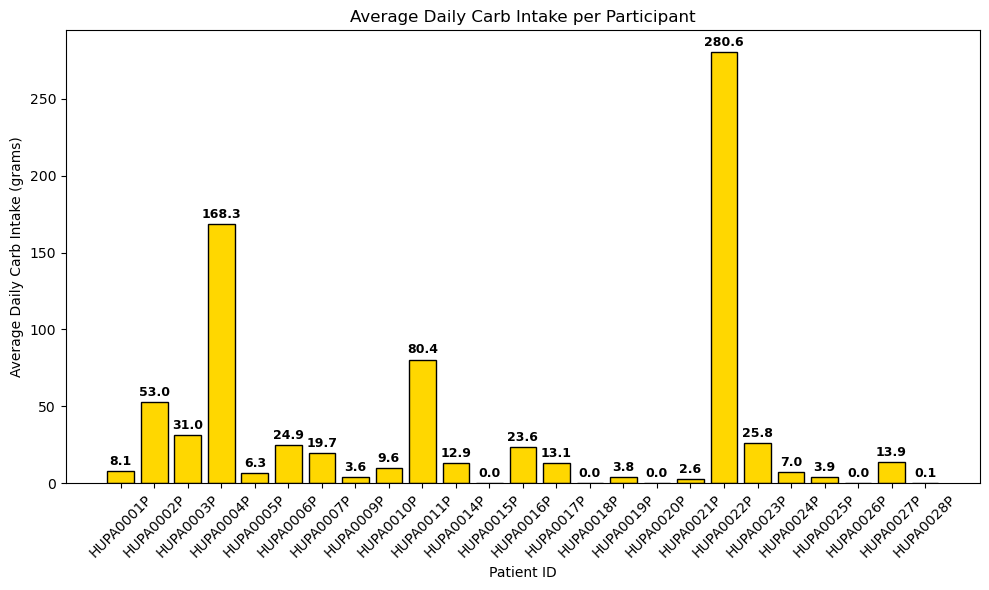

In [302]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
bars = plt.bar(avg_carbs_per_day["patient_id"], avg_carbs_per_day["avg_daily_carb_g"],
               color="gold", edgecolor="black")

plt.title("Average Daily Carb Intake per Participant")
plt.xlabel("Patient ID")
plt.ylabel("Average Daily Carb Intake (grams)")
plt.xticks(rotation=45)

# Add data labels
for i, v in enumerate(avg_carbs_per_day["avg_daily_carb_g"]):
    plt.text(i, v + 2, f"{v:.1f}", ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

#### What is the distribution of glucose readings (min, max, mean, median)?

In [304]:
glucose_stats = dfT1DData["glucose"].describe()

min_val = dfT1DData["glucose"].min()
max_val = dfT1DData["glucose"].max()
mean_val = dfT1DData["glucose"].mean()
median_val = dfT1DData["glucose"].median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")

Min: 40.0
Max: 444.0
Mean: 153.28
Median: 142.00


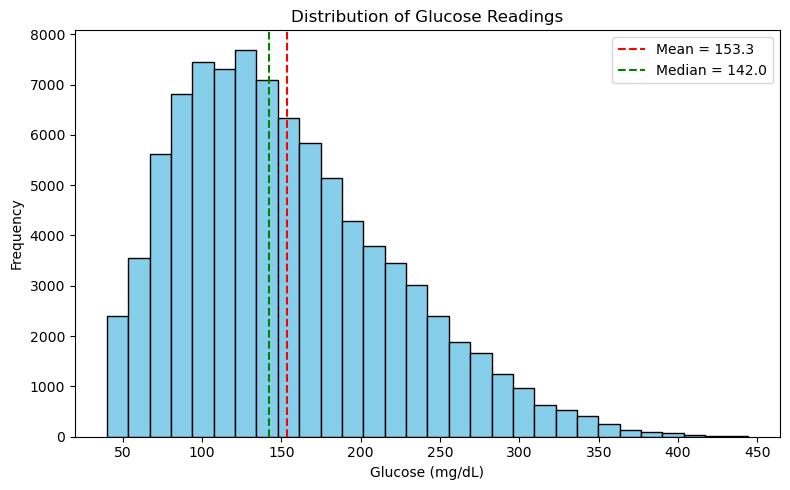

In [305]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dfT1DData["glucose"], bins=30, color="skyblue", edgecolor="black")
plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean = {mean_val:.1f}")
plt.axvline(median_val, color="green", linestyle="--", label=f"Median = {median_val:.1f}")
plt.title("Distribution of Glucose Readings")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

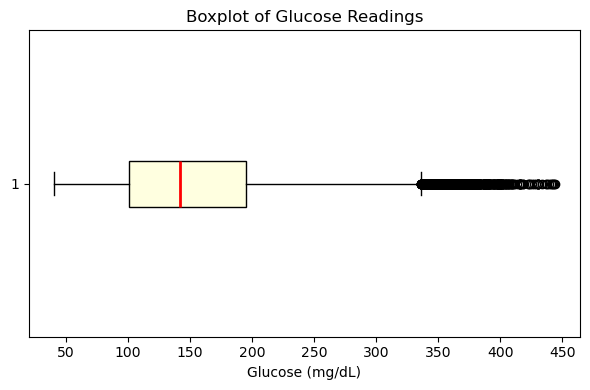

In [306]:
plt.figure(figsize=(6,4))
plt.boxplot(dfT1DData["glucose"].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightyellow", color="black"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Boxplot of Glucose Readings")
plt.xlabel("Glucose (mg/dL)")
plt.tight_layout()
plt.show()

#### What is the average daily step count per participant?

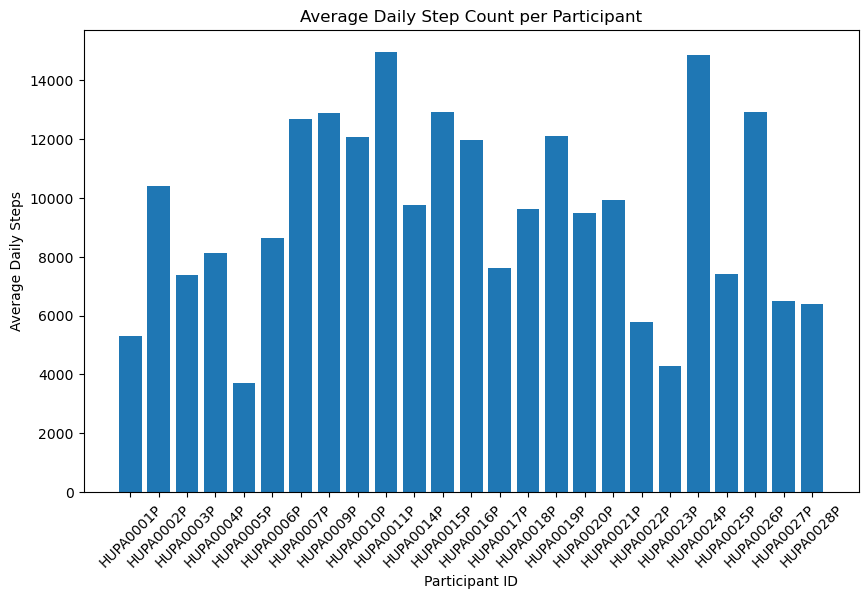

,patient_id,avg_daily_steps
0,HUPA0001P,5315.933333
1,HUPA0002P,10402.500000
2,HUPA0003P,7381.428571
3,HUPA0004P,8146.916667
4,HUPA0005P,3714.500000


In [308]:
# Average daily step count per participant
avg_steps = (
    dfT1DData.groupby(['patient_id', 'date'])['steps'].sum().reset_index()
    .groupby('patient_id')['steps'].mean()
    .reset_index(name='avg_daily_steps')
)

import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10,6))
plt.bar(avg_steps['patient_id'], avg_steps['avg_daily_steps'])
plt.xlabel("Participant ID")
plt.ylabel("Average Daily Steps")
plt.title("Average Daily Step Count per Participant")
plt.xticks(rotation=45)
plt.show()

avg_steps.head()

#### Are higher step counts associated with lower glucose levels?

In [310]:
# Correlation
corr_steps_glucose = dfT1DData["steps"].corr(dfT1DData["glucose"])
print(f"Correlation between steps and glucose: {corr_steps_glucose:.2f}")

Correlation between steps and glucose: 0.03


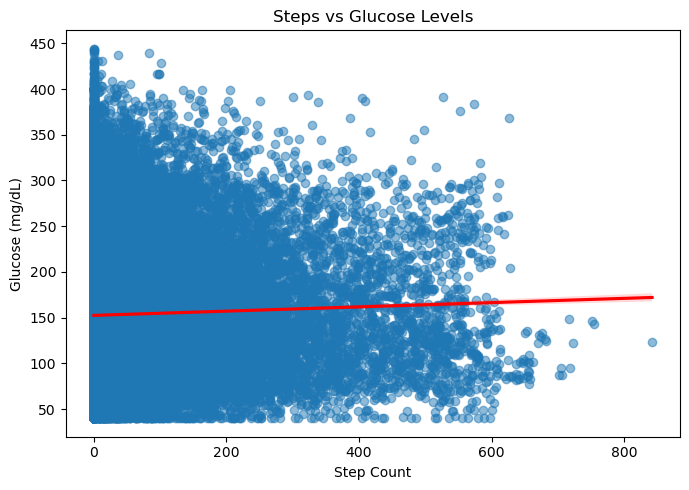

In [311]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(
    data=dfT1DData,
    x="steps",
    y="glucose",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Steps vs Glucose Levels")
plt.xlabel("Step Count")
plt.ylabel("Glucose (mg/dL)")
plt.tight_layout()
plt.show()

#### How does heart rate vary across the day (morning, afternoon, evening, night)?

         time_of_day  heart_rate
0  Afternoon (12–18)   81.849082
1    Evening (18–24)   82.122963
2     Morning (6–12)   73.927634
3        Night (0–6)   67.096566


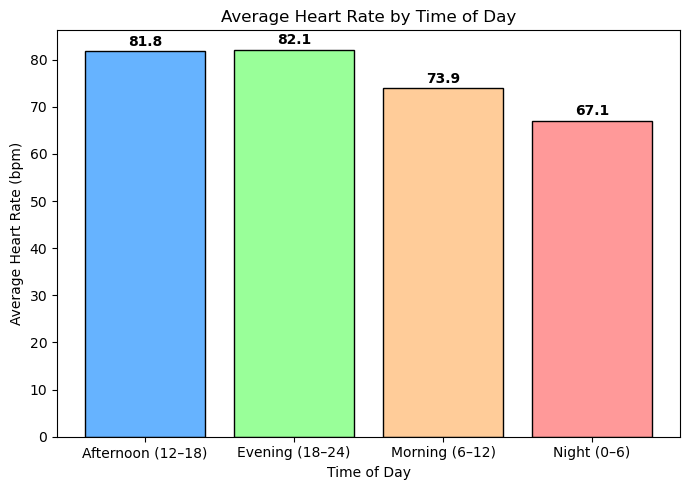

In [313]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure date_time is datetime
df = dfT1DData.copy()
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

# Extract hour
df["hour"] = df["date_time"].dt.hour

# Define time-of-day bins
def time_of_day(hour):
    if 6 <= hour < 12:
        return "Morning (6–12)"
    elif 12 <= hour < 18:
        return "Afternoon (12–18)"
    elif 18 <= hour < 24:
        return "Evening (18–24)"
    else:
        return "Night (0–6)"

df["time_of_day"] = df["hour"].apply(time_of_day)

# Average heart rate per time of day
heart_rate_trends = df.groupby("time_of_day")["heart_rate"].mean().reset_index()

print(heart_rate_trends)

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(heart_rate_trends["time_of_day"], heart_rate_trends["heart_rate"],
               color=["#66b3ff","#99ff99","#ffcc99","#ff9999"], edgecolor="black")

plt.title("Average Heart Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Heart Rate (bpm)")
plt.xticks(rotation=0)

# Add data labels
for i, v in enumerate(heart_rate_trends["heart_rate"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

#### Carb Intake Without Insulin: Glucose Outcomes Across Patients

glucose_outcome  Hypoglycemia (<70)  Normal (70-180)  Hyperglycemia (>180)
patient_id                                                                
HUPA0011P                         0               29                    22

Overall outcome distribution:
 glucose_outcome
Normal (70-180)         29
Hyperglycemia (>180)    22
Hypoglycemia (<70)       0
Name: count, dtype: int64


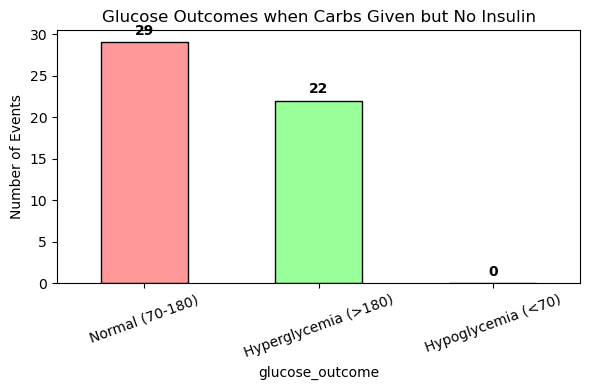

In [315]:
import pandas as pd
import matplotlib.pyplot as plt

df = dfT1DData.copy()

# Ensure numeric types
for col in ["carb_input_g","bolus_volume_delivered","basal_rate","glucose"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Scenario: carbs eaten, but no bolus or basal
scenario = df[(df["carb_input_g"] >= 10) & 
              (df["bolus_volume_delivered"] == 0) & 
              (df["basal_rate"] == 0)].copy()

# Outcome categories
scenario["glucose_outcome"] = pd.cut(
    scenario["glucose"],
    bins=[-float("inf"), 70, 180, float("inf")],
    labels=["Hypoglycemia (<70)", "Normal (70-180)", "Hyperglycemia (>180)"]
)

# Count outcomes per patient
outcome_counts = scenario.groupby(["patient_id","glucose_outcome"]).size().unstack(fill_value=0)

print(outcome_counts)

# Overall summary
overall_counts = scenario["glucose_outcome"].value_counts()
print("\nOverall outcome distribution:\n", overall_counts)

# Bar chart with values
plt.figure(figsize=(6,4))
bars = overall_counts.plot(kind="bar", color=["#ff9999","#99ff99","#66b3ff"], edgecolor="black")
plt.title("Glucose Outcomes when Carbs Given but No Insulin")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)

# Add values on top
for i, v in enumerate(overall_counts):
    plt.text(i, v+0.5, str(v), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

#### Identifying the patients who had impact of missing insulin dosing during carbohydrate intake

In [317]:
# Patients who had carbs >=10g but no bolus or basal
patients_with_events = scenario["patient_id"].unique()

print("Patients with carbs but no insulin events:")
print(patients_with_events)

# Count how many such events per patient and their glucose outcomes
patient_event_summary = scenario.groupby(["patient_id","glucose_outcome"]).size().unstack(fill_value=0)

print("\nSummary of events per patient:")
print(patient_event_summary)

Patients with carbs but no insulin events:
['HUPA0011P']

Summary of events per patient:
glucose_outcome  Hypoglycemia (<70)  Normal (70-180)  Hyperglycemia (>180)
patient_id                                                                
HUPA0011P                         0               29                    22


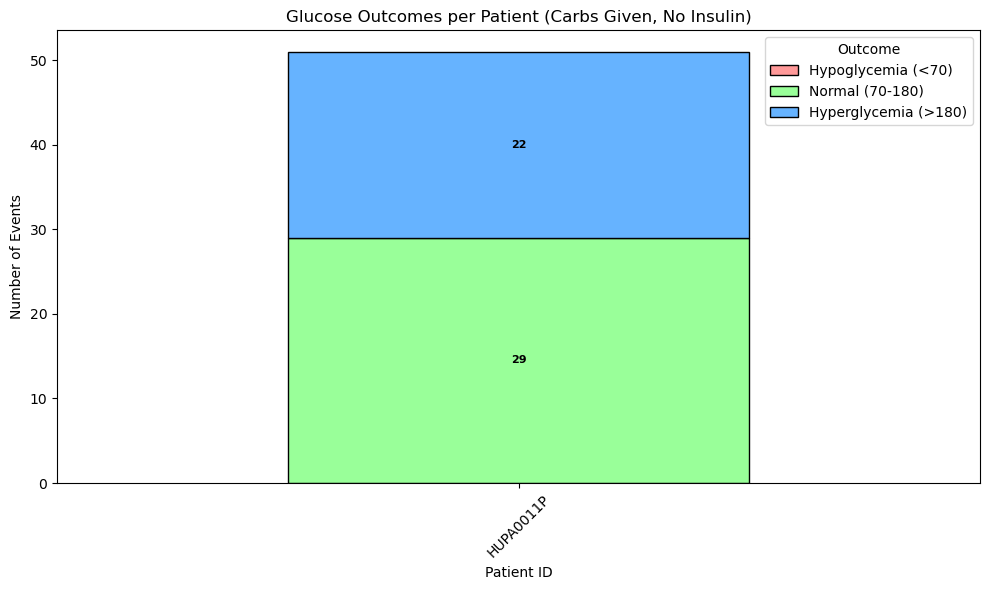

In [318]:
import matplotlib.pyplot as plt

patient_event_summary.plot(kind="bar", stacked=True, figsize=(10,6),
                           color=["#ff9999","#99ff99","#66b3ff"], edgecolor="black")

plt.title("Glucose Outcomes per Patient (Carbs Given, No Insulin)")
plt.xlabel("Patient ID")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.legend(title="Outcome")

# Add value labels
for i, row in enumerate(patient_event_summary.values):
    for j, v in enumerate(row):
        if v > 0:
            plt.text(i, sum(row[:j]) + v/2, str(v), ha="center", va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

#### Checking how patients' sleep quality is affecting their Glucose readings


In-range vs Out-of-range by Sleep Quality Group:

  SleepQualityGroup      n  in_range_pct  out_of_range_pct
0        Poor (1–4)  46563     63.717973         36.282027
1        Fair (5–6)  39517     56.998254         43.001746
2        Good (7–8)   4023     78.896346         21.103654


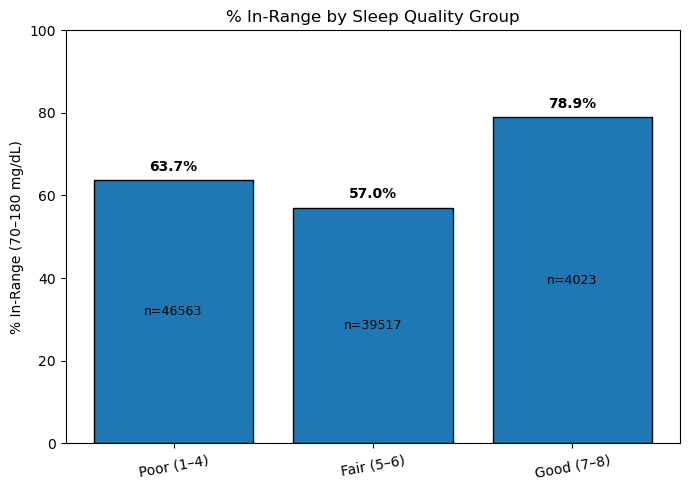

In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 0) Start from your working df ---
df = dfT1DData.copy()

# --- 1) Ensure numeric & drop missing needed fields ---
df["glucose"] = pd.to_numeric(df["glucose"], errors="coerce")
df["Sleep Quality (1-10)"] = pd.to_numeric(df["Sleep Quality (1-10)"], errors="coerce")
df = df.dropna(subset=["glucose", "Sleep Quality (1-10)"])

# --- 2) Create sleep-quality bins (overall, not per patient) ---
bins = [0, 4, 6, 8, 10]
labels = ["Poor (1–4)", "Fair (5–6)", "Good (7–8)", "Excellent (9–10)"]
df["SleepQualityGroup"] = pd.cut(
    df["Sleep Quality (1-10)"], bins=bins, labels=labels, include_lowest=True, ordered=True
)

# --- 3) In-range flag (70–180 mg/dL) ---
df["in_range"] = df["glucose"].between(70, 180).astype(int)

# --- 4) Aggregate to % in-range (and counts) by sleep-quality group ---
summary = (
    df.groupby("SleepQualityGroup", observed=True)
      .agg(
          n=("glucose", "size"),
          in_range_pct=("in_range", "mean")
      )
      .reset_index()
)
summary["out_of_range_pct"] = 1 - summary["in_range_pct"]
summary["in_range_pct"] *= 100
summary["out_of_range_pct"] *= 100

print("\nIn-range vs Out-of-range by Sleep Quality Group:\n")
print(summary)

# --- 5A) Bar chart: % In-Range only (with % labels and n on bars) ---
plt.figure(figsize=(7,5))
bars = plt.bar(summary["SleepQualityGroup"], summary["in_range_pct"], edgecolor="black")
plt.title("% In-Range by Sleep Quality Group")
plt.ylabel("% In-Range (70–180 mg/dL)")
plt.xticks(rotation=10)

# Labels: percentage on top + sample size inside
ymax = float(summary["in_range_pct"].max() if len(summary) else 0)
for i, (pct, n) in enumerate(zip(summary["in_range_pct"], summary["n"])):
    plt.text(i, pct + max(0.5, 0.02*ymax), f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")
    plt.text(i, pct/2 if pct > 0 else 1, f"n={n}", ha="center", va="center", fontsize=9)

plt.ylim(0, max(100, ymax*1.20))
plt.tight_layout()
plt.show()

